### import and path

In [2]:
!pip list |grep Shapely


Shapely                  1.8.2


In [3]:
import socket
import sys
import pickle
import os
import time
from pprint import pprint

sys.path.append('/home/lxh/dev/DRL-urban-planning')
home_dir= '/home/lxh/dev/drl_urban_planning/'
root_dir = '/home/lxh/dev/drl_urban_planning/'

### demo

In [23]:
from urban_planning.envs import CityEnv
from urban_planning.envs import city_config
from urban_planning.utils.config import Config

In [24]:
id = 'dhm'
seed = 111
temp = False
cfg = Config(id, seed, temp, root_dir)
env = CityEnv(cfg)

In [26]:
dhm_concept_path= '/home/lxh/dev/DRL-urban-planning/urban_planning/cfg/test_data/real/dhm/init_plan_dhm_concept.pickle'
m=pickle.load(open(dhm_concept_path, 'rb'))
gdf=m['gdf']
gdf.to_file('dhm_concept.geojson', driver='GeoJSON')
pprint(m)
with open('dhm_concept.txt', 'w') as file:
    for key, value in m.items():
        file.write(f'{key}: {value}\n')

{'concept': [{'distance': 200,
              'geometry': <shapely.geometry.point.Point object at 0x7fe19f619130>,
              'land_use': [5, 6],
              'type': 'center'},
             {'distance': 50,
              'geometry': <shapely.geometry.linestring.LineString object at 0x7fe19f619af0>,
              'land_use': [12],
              'type': 'axis'},
             {'distance': 50,
              'geometry': <shapely.geometry.linestring.LineString object at 0x7fe19f619400>,
              'land_use': [7, 8],
              'type': 'axis'}],
 'gdf':      type  existence                                           geometry
id                                                                     
0       2       True            LINESTRING (0.000 0.000, 432.000 0.000)
1       2       True         LINESTRING (432.000 0.000, 1224.000 0.000)
2       2       True        LINESTRING (1224.000 0.000, 1867.000 0.000)
3       2       True        LINESTRING (0.000 2768.000, 0.000 2414.000)
4   

     type  existence                                           geometry
id                                                                     
0       2       True            LINESTRING (0.000 0.000, 432.000 0.000)
1       2       True         LINESTRING (432.000 0.000, 1224.000 0.000)
2       2       True        LINESTRING (1224.000 0.000, 1867.000 0.000)
3       2       True        LINESTRING (0.000 2768.000, 0.000 2414.000)
4       2       True        LINESTRING (0.000 2414.000, 0.000 1932.000)
..    ...        ...                                                ...
264     1       True  POLYGON ((1545.000 1785.000, 1457.000 1785.000...
265     1       True  POLYGON ((1618.000 1694.000, 1545.000 1785.000...
266     1       True  POLYGON ((1618.000 1303.000, 1513.000 1303.000...
267     1       True  POLYGON ((573.000 1122.000, 573.000 1322.000, ...
268     1       True  POLYGON ((933.000 1122.000, 753.000 1122.000, ...

[269 rows x 3 columns]


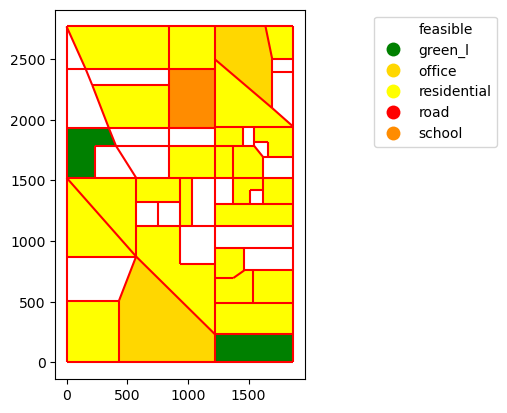

In [14]:
gdf = m['gdf']
print(gdf)
env.load_plan(gdf)
env.visualize()

In [ ]:
model_path = os.path.join(root_dir, id, str(seed), 'plan', 'plan.p')
d = pickle.load(open(model_path, 'rb'))

print(d)

[{'road_network': -1.0, 'life_circle': 0.6567878366871375, 'greenness': 0.4095737512214715, 'concept': -1.0, 'life_circle_info': {'life_circle_15min': 0.9103448275862068, 'life_circle_10min': 0.6413793103448276, 'life_circle_5min': 0.3310344827586207, 'life_circle_10min_area': 0.5280284352771545, 'decentralization_reward': 0.3081705268461961, 'utility': 0.2966413114694568, 'shopping': 0.5172413793103449, 'working': 0.41379310344827586, 'education': 0.7586206896551724, 'medical care': 0.7586206896551724, 'entertainment': 0.7586206896551724}, 'concept_info': {}, 'land_use_reward': 3.0367250979700215, 'gdf':      type  existence                                           geometry  \
id                                                                        
0       2       True            LINESTRING (0.000 0.000, 432.000 0.000)   
1       2       True         LINESTRING (432.000 0.000, 1224.000 0.000)   
2       2       True        LINESTRING (1224.000 0.000, 1867.000 0.000)   
3       2   

In [10]:
#ga solution
gdf = d[0]['gdf']
print(gdf)

     type  existence                                           geometry  \
id                                                                        
0       2       True            LINESTRING (0.000 0.000, 432.000 0.000)   
1       2       True         LINESTRING (432.000 0.000, 1224.000 0.000)   
2       2       True        LINESTRING (1224.000 0.000, 1867.000 0.000)   
3       2       True        LINESTRING (0.000 2768.000, 0.000 2414.000)   
4       2      False  LINESTRING (0.000 2414.000, 0.000 2284.000, 0....   
..    ...        ...                                                ...   
410     2       True    LINESTRING (407.000 1785.000, 492.000 1785.000)   
411     2       True    LINESTRING (692.000 1785.000, 492.000 1785.000)   
412     2       True    LINESTRING (492.000 1650.331, 492.000 1785.000)   
413     5       True  POLYGON ((492.000 1785.000, 692.000 1785.000, ...   
414     8       True  POLYGON ((492.000 1785.000, 492.000 1650.331, ...   

        rect       eqi  

### load plan and score

In [11]:
env.load_plan(gdf)
env.score_plan()

reward: 3.0367250979700215
{   'road_network': -1.0,
    'life_circle': 0.6567878366871375,
    'greenness': 0.4095737512214715,
    'road_network_info': {},
    'life_circle_info': {   'life_circle_15min': 0.9103448275862068,
                            'life_circle_10min': 0.6413793103448276,
                            'life_circle_5min': 0.3310344827586207,
                            'life_circle_10min_area': 0.5280284352771545,
                            'decentralization_reward': 0.3081705268461961,
                            'utility': 0.2966413114694568,
                            'shopping': 0.5172413793103449,
                            'working': 0.41379310344827586,
                            'education': 0.7586206896551724,
                            'medical care': 0.7586206896551724,
                            'entertainment': 0.7586206896551724}}


(3.0367250979700215,
 {'road_network': -1.0,
  'life_circle': 0.6567878366871375,
  'greenness': 0.4095737512214715,
  'road_network_info': {},
  'life_circle_info': {'life_circle_15min': 0.9103448275862068,
   'life_circle_10min': 0.6413793103448276,
   'life_circle_5min': 0.3310344827586207,
   'life_circle_10min_area': 0.5280284352771545,
   'decentralization_reward': 0.3081705268461961,
   'utility': 0.2966413114694568,
   'shopping': 0.5172413793103449,
   'working': 0.41379310344827586,
   'education': 0.7586206896551724,
   'medical care': 0.7586206896551724,
   'entertainment': 0.7586206896551724}})

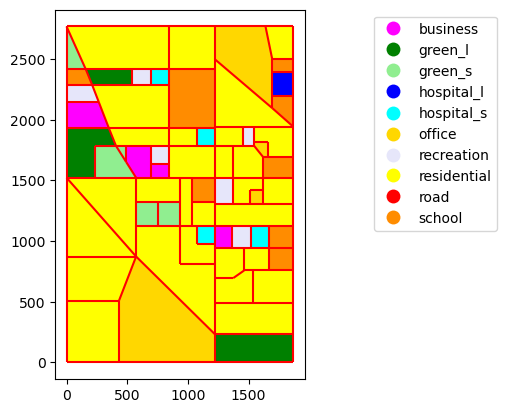

In [12]:
env.visualize()

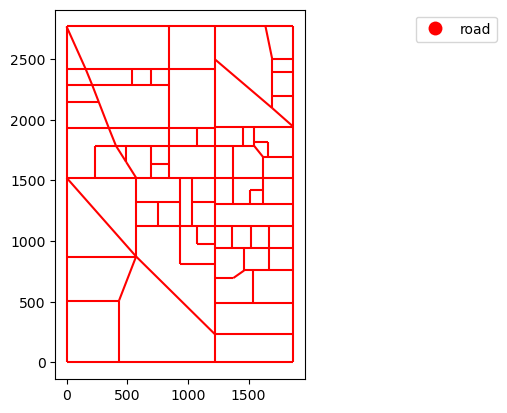

In [13]:
env.visualize_road_and_boundary()

In [14]:
import geopandas as gpd

try:
    # Read GeoJSON file into a GeoDataFrame
    gdf = gpd.read_file('../results/dhm.geojson')
    
    # Verify the data was loaded correctly
    print(f"Loaded {len(gdf)} features")
    print(f"Columns: {gdf.columns}")
    
except FileNotFoundError:
    print("Error: dhm.geojson file not found")
except Exception as e:
    print(f"Error loading GeoJSON: {e}")

Loaded 465 features
Columns: Index(['id', 'type', 'existence', 'rect', 'eqi', 'sc', 'geometry'], dtype='object')


In [ ]:
env.load_plan(gdf)
env.score_plan()

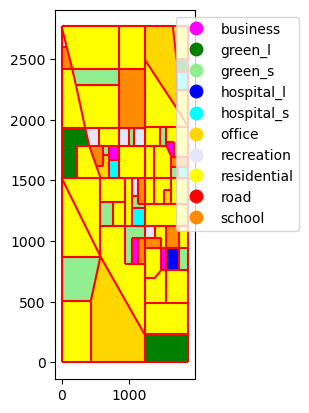

In [16]:
env.visualize()